In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/problem2-used-car-price-prediction/sample_submission.csv
/kaggle/input/problem2-used-car-price-prediction/train.csv
/kaggle/input/problem2-used-car-price-prediction/test.csv


# Import necessary modules and load the datasets

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
df = pd.read_csv("/kaggle/input/problem2-used-car-price-prediction/train.csv")
test = pd.read_csv("/kaggle/input/problem2-used-car-price-prediction/test.csv")

In [ ]:
df.head()

,Id,Mileage,EngineSize,Horsepower,Age,NumberOfDoors,Weight,FuelCapacity,TopSpeed,Acceleration,...,FuelType,Color,Condition,SafetyRating,ComfortRating,TechnologyRating,BrandPopularity,IFeature,RFeature,Price
0,1,44166.12500,1.477207,175.418191,13,2,3951.090535,6.352488,148.548296,10.095521,...,0,1,2,2,1,2,5,-0.814451,175.402641,67840.07026
1,2,50947.97343,0.905297,185.245504,3,4,4529.185652,13.086345,164.255196,6.150027,...,2,2,2,5,5,3,4,0.560742,185.249967,84080.37107
2,3,43809.07121,4.438929,271.568339,12,2,4554.484288,25.594876,118.030078,11.073373,...,0,1,3,2,4,5,2,-0.815535,271.568403,97091.10956
3,4,41348.83624,1.696821,200.168775,16,4,3604.213295,8.481377,119.212560,6.990170,...,0,3,2,1,5,3,5,0.526671,200.174173,67987.03732
4,5,81010.00986,1.356274,295.206830,18,4,4264.749981,12.205729,131.560905,10.606177,...,0,0,2,1,4,1,4,-0.573623,295.200060,97047.28827


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                500 non-null    int64  
 1   Mileage           500 non-null    float64
 2   EngineSize        500 non-null    float64
 3   Horsepower        500 non-null    float64
 4   Age               500 non-null    int64  
 5   NumberOfDoors     500 non-null    int64  
 6   Weight            500 non-null    float64
 7   FuelCapacity      500 non-null    float64
 8   TopSpeed          500 non-null    float64
 9   Acceleration      500 non-null    float64
 10  Wheelbase         500 non-null    float64
 11  Make              500 non-null    int64  
 12  Model             500 non-null    int64  
 13  Transmission      500 non-null    int64  
 14  FuelType          500 non-null    int64  
 15  Color             500 non-null    int64  
 16  Condition         500 non-null    int64  
 1

Clearly there are no categorical features - no need handling categorical values.
Also there are no null values - Missing value analysis not needed

In [ ]:
df

,Id,Mileage,EngineSize,Horsepower,Age,NumberOfDoors,Weight,FuelCapacity,TopSpeed,Acceleration,...,FuelType,Color,Condition,SafetyRating,ComfortRating,TechnologyRating,BrandPopularity,IFeature,RFeature,Price
0,1,44166.12500,1.477207,175.418191,13,2,3951.090535,6.352488,148.548296,10.095521,...,0,1,2,2,1,2,5,-0.814451,175.402641,67840.07026
1,2,50947.97343,0.905297,185.245504,3,4,4529.185652,13.086345,164.255196,6.150027,...,2,2,2,5,5,3,4,0.560742,185.249967,84080.37107
2,3,43809.07121,4.438929,271.568339,12,2,4554.484288,25.594876,118.030078,11.073373,...,0,1,3,2,4,5,2,-0.815535,271.568403,97091.10956
3,4,41348.83624,1.696821,200.168775,16,4,3604.213295,8.481377,119.212560,6.990170,...,0,3,2,1,5,3,5,0.526671,200.174173,67987.03732
4,5,81010.00986,1.356274,295.206830,18,4,4264.749981,12.205729,131.560905,10.606177,...,0,0,2,1,4,1,4,-0.573623,295.200060,97047.28827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,30482.53494,1.845924,176.709722,11,2,3673.578232,14.474696,128.329698,3.308995,...,1,1,1,1,5,2,2,0.887282,176.710375,65644.15545
496,497,54442.67543,2.767127,195.970012,7,4,3621.234567,15.465032,186.937318,8.453638,...,1,3,4,3,2,1,2,-0.755371,195.981589,80493.99774
497,498,53881.79986,2.027909,264.793589,19,4,3445.707015,18.970918,163.196566,8.505135,...,1,2,5,4,3,3,3,-0.565728,264.786143,92591.39311
498,499,49337.46054,3.810309,198.447053,15,2,3688.223992,6.659986,147.740127,7.923552,...,0,0,4,1,1,5,4,-1.175552,198.441343,71713.07958


In [ ]:
df.shape

(500, 24)

In [ ]:
# Since we know that id doesn't influence the price, we remove it
df = df.drop("Id",axis = 1)

In [ ]:
df

,Mileage,EngineSize,Horsepower,Age,NumberOfDoors,Weight,FuelCapacity,TopSpeed,Acceleration,Wheelbase,...,FuelType,Color,Condition,SafetyRating,ComfortRating,TechnologyRating,BrandPopularity,IFeature,RFeature,Price
0,44166.12500,1.477207,175.418191,13,2,3951.090535,6.352488,148.548296,10.095521,106.560966,...,0,1,2,2,1,2,5,-0.814451,175.402641,67840.07026
1,50947.97343,0.905297,185.245504,3,4,4529.185652,13.086345,164.255196,6.150027,112.006852,...,2,2,2,5,5,3,4,0.560742,185.249967,84080.37107
2,43809.07121,4.438929,271.568339,12,2,4554.484288,25.594876,118.030078,11.073373,97.607125,...,0,1,3,2,4,5,2,-0.815535,271.568403,97091.10956
3,41348.83624,1.696821,200.168775,16,4,3604.213295,8.481377,119.212560,6.990170,101.442649,...,0,3,2,1,5,3,5,0.526671,200.174173,67987.03732
4,81010.00986,1.356274,295.206830,18,4,4264.749981,12.205729,131.560905,10.606177,125.193836,...,0,0,2,1,4,1,4,-0.573623,295.200060,97047.28827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,30482.53494,1.845924,176.709722,11,2,3673.578232,14.474696,128.329698,3.308995,110.016621,...,1,1,1,1,5,2,2,0.887282,176.710375,65644.15545
496,54442.67543,2.767127,195.970012,7,4,3621.234567,15.465032,186.937318,8.453638,101.859629,...,1,3,4,3,2,1,2,-0.755371,195.981589,80493.99774
497,53881.79986,2.027909,264.793589,19,4,3445.707015,18.970918,163.196566,8.505135,130.684353,...,1,2,5,4,3,3,3,-0.565728,264.786143,92591.39311
498,49337.46054,3.810309,198.447053,15,2,3688.223992,6.659986,147.740127,7.923552,118.646877,...,0,0,4,1,1,5,4,-1.175552,198.441343,71713.07958


## Exploratory data analysis

In [ ]:
df.corr()

,Mileage,EngineSize,Horsepower,Age,NumberOfDoors,Weight,FuelCapacity,TopSpeed,Acceleration,Wheelbase,...,FuelType,Color,Condition,SafetyRating,ComfortRating,TechnologyRating,BrandPopularity,IFeature,RFeature,Price
Mileage,1.000000,-0.066497,0.058847,0.009012,0.001868,0.074914,-0.012168,0.001633,0.040591,-0.017540,...,0.020235,-0.030734,-0.101240,-0.015465,0.050054,0.129900,-0.017852,-0.052959,0.058835,0.204987
EngineSize,-0.066497,1.000000,-0.025218,0.037232,0.010891,0.042486,0.064261,0.018098,0.005980,0.047497,...,0.035937,0.147587,0.003476,0.002358,-0.065225,-0.010143,-0.080781,-0.027854,-0.025219,-0.013047
Horsepower,0.058847,-0.025218,1.000000,0.017073,0.075397,0.017326,-0.013919,-0.103146,-0.055016,0.042592,...,-0.043071,0.047979,0.025627,-0.045011,0.022216,-0.010615,-0.014834,-0.001585,1.000000,0.910584
Age,0.009012,0.037232,0.017073,1.000000,0.004775,0.003797,-0.054262,0.017095,-0.030927,0.028339,...,0.028253,0.058752,0.003671,0.001563,-0.058022,-0.098551,0.035426,0.076178,0.017077,-0.320170
NumberOfDoors,0.001868,0.010891,0.075397,0.004775,1.000000,0.032235,0.012243,0.000011,0.004242,-0.000683,...,-0.000256,0.023425,-0.014054,-0.068173,0.003469,0.006999,-0.013063,-0.043561,0.075416,0.053316
Weight,0.074914,0.042486,0.017326,0.003797,0.032235,1.000000,-0.072891,-0.038415,-0.067957,-0.006156,...,0.020994,0.002373,-0.016880,-0.006151,-0.068894,-0.070544,0.036743,0.024919,0.017332,0.027777
FuelCapacity,-0.012168,0.064261,-0.013919,-0.054262,0.012243,-0.072891,1.000000,-0.004999,0.010876,0.008862,...,0.007275,-0.031372,-0.055917,-0.027695,0.022067,-0.007096,-0.109820,0.014985,-0.013917,-0.004493
TopSpeed,0.001633,0.018098,-0.103146,0.017095,0.000011,-0.038415,-0.004999,1.000000,0.023091,-0.072373,...,-0.012848,0.038947,0.009847,0.078095,0.016386,0.000403,0.022768,-0.083268,-0.103144,-0.085777
Acceleration,0.040591,0.005980,-0.055016,-0.030927,0.004242,-0.067957,0.010876,0.023091,1.000000,-0.006107,...,0.019964,-0.050372,-0.057950,0.019333,-0.002194,0.044338,-0.019416,0.004171,-0.055016,-0.030238
Wheelbase,-0.017540,0.047497,0.042592,0.028339,-0.000683,-0.006156,0.008862,-0.072373,-0.006107,1.000000,...,-0.004205,0.028512,-0.018956,0.091352,0.062446,-0.020915,0.002467,0.000288,0.042583,0.041879


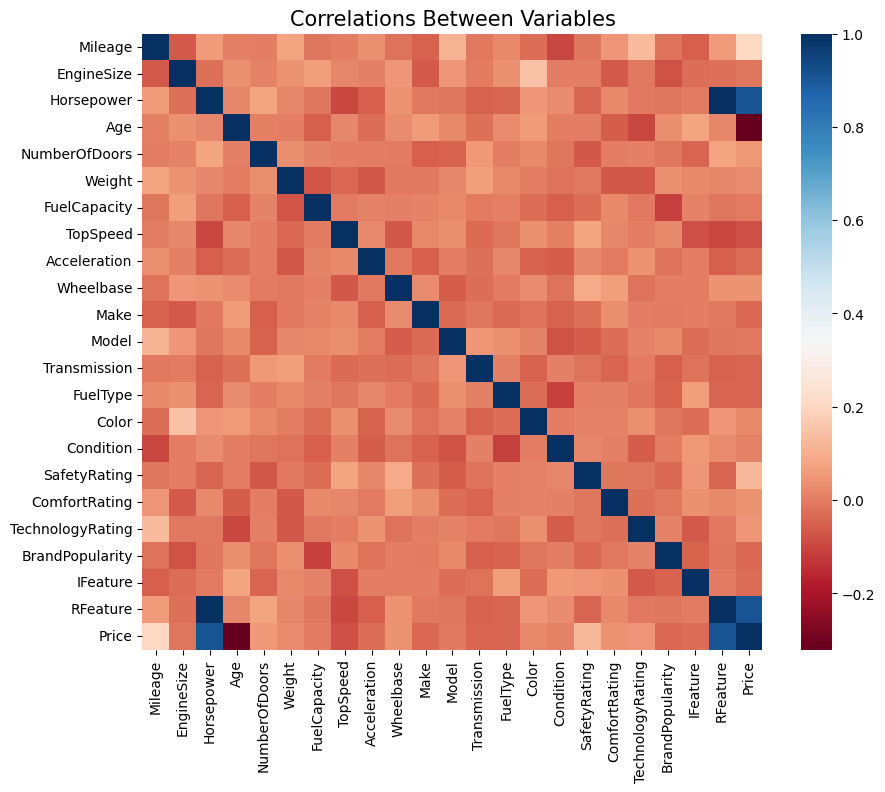

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="RdBu")
plt.title("Correlations Between Variables", size=15)
plt.show()

We can clearly notice that price depends more on the Age, horsepower and Rfeature compared to other features fromt the heat map

In [ ]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [ ]:
# Splitting of traind and test data
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 100)

In [ ]:
X_train

,Mileage,EngineSize,Horsepower,Age,NumberOfDoors,Weight,FuelCapacity,TopSpeed,Acceleration,Wheelbase,...,Transmission,FuelType,Color,Condition,SafetyRating,ComfortRating,TechnologyRating,BrandPopularity,IFeature,RFeature
153,37987.22620,3.113518,210.482971,14,4,2500.090015,9.190945,138.081186,5.971652,123.379924,...,0,2,4,2,3,2,2,1,-0.820705,210.477534
84,45175.27884,0.726968,260.299726,19,2,4149.110496,17.549519,137.321436,8.979009,111.586779,...,0,1,1,3,2,2,3,4,0.987015,260.291632
310,53329.04416,2.659856,210.838778,11,4,2396.174071,18.995341,153.286256,7.623062,113.167541,...,0,1,1,5,3,1,3,2,-2.265666,210.833056
494,55580.43052,1.957326,292.430442,7,4,4231.080115,17.788936,165.278972,5.436753,119.595887,...,1,0,1,5,2,4,3,4,-1.852025,292.419310
126,45939.09228,2.801792,171.761300,6,2,3634.567212,20.893982,148.109721,11.700095,99.801132,...,1,0,1,3,5,2,3,5,-0.990267,171.768521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,56481.67939,1.874437,241.254913,4,4,3840.428620,10.530223,142.063379,9.316056,119.583757,...,1,0,4,1,5,1,4,1,-1.643098,241.244905
359,246229.82880,1.276060,205.217797,16,4,2480.006840,19.965199,115.101046,5.202050,104.615585,...,1,2,0,3,2,5,4,1,1.335043,205.202313
323,62318.71214,1.154020,193.275161,17,2,3371.250916,13.917076,172.310234,7.272761,103.961155,...,0,1,1,3,5,5,3,5,-0.340505,193.290771
280,46461.05545,1.394295,168.134613,10,2,2764.382027,15.848836,150.836555,5.263646,108.268927,...,0,0,2,2,2,2,4,3,1.816906,168.126008


In [ ]:
y_test.shape

(150,)

Multiple Linear regresssion model

In [ ]:
reg_model = LinearRegression()

In [ ]:
#Fitting the Multiple Linear Regression model
reg_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Predicting the Test and Train set result

y_pred= reg_model.predict(X_test)

In [ ]:
def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    r_squared = r2_score(y, predictions)
    return mae, mse, rmse, r_squared

In [ ]:
mae, mse, rmse, r_squared = evaluation(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)

MAE: 930.9365387116721
MSE: 1383018.7806702193
RMSE: 1176.0181889198054
R2 Score: 0.9952413723920822
------------------------------


## Evaluating test set on the trained model

In [ ]:
test.head()

,Id,Mileage,EngineSize,Horsepower,Age,NumberOfDoors,Weight,FuelCapacity,TopSpeed,Acceleration,...,Transmission,FuelType,Color,Condition,SafetyRating,ComfortRating,TechnologyRating,BrandPopularity,IFeature,RFeature
0,501,56835.11952,3.801741,188.479964,6,2,3756.241546,15.676035,162.643196,9.259340,...,1,2,3,1,5,4,5,2,0.782985,188.493258
1,502,66812.87098,3.155901,131.584248,14,4,3197.661312,22.322568,145.081875,8.156202,...,1,0,1,2,5,1,1,3,-0.778534,131.568912
2,503,33380.99767,3.977530,133.877102,12,2,4111.438465,27.514813,150.016981,6.758564,...,0,0,0,1,4,3,1,5,-0.230726,133.877236
3,504,21397.17244,1.596092,215.982591,18,4,2820.206934,17.105866,146.930873,8.516852,...,1,2,2,5,1,4,4,2,-0.824586,215.987039
4,505,71309.60750,1.512820,103.616371,9,2,4903.849500,19.200835,148.654042,6.917950,...,0,2,0,1,3,3,1,2,-0.681389,103.614481


In [ ]:
test1 = test.drop("Id",axis =1)

In [ ]:
y_test_pred= reg_model.predict(test1)

In [ ]:
y_test_pred

array([ 85365.13136905,  60334.5718944 ,  59836.3544948 ,  70673.09409495,
        52601.22605868,  92688.33908508,  69782.20924255,  72707.26746834,
        86930.5228014 ,  53458.79842825, 106874.20340443,  33309.23505297,
        92780.79916742,  99672.85081003,  96677.66489435, 101629.86102461,
       107402.43467582,  72890.26754669,  73467.03274294,  68790.34211689,
        73659.24456107,  89337.51309746,  81693.77262187, 103292.67209274,
        45596.78199923,  48295.22047499,  35017.49237111,  96043.56352365,
       101151.33879073,  77260.22003396,  84014.88452391,  64451.61149805,
        96772.48333171, 102968.75702131,  53653.59981217,  61679.55620594,
        76669.65472357,  87136.25026692, 105199.16266661, 124738.11615073,
        60529.14215722,  65236.48783273,  63836.59266263,  66018.98904671,
        43051.29868677,  67960.90852144,  86374.5508917 ,  58647.74584424,
        65142.29842522, 108668.63607507,  91302.57886175,  88114.45187401,
        89450.28299968, 1

In [ ]:
submission = pd.DataFrame({'Id': test['Id'], 'Price': y_test_pred})

In [ ]:
submission

,Id,Price
0,501,85365.131369
1,502,60334.571894
2,503,59836.354495
3,504,70673.094095
4,505,52601.226059
...,...,...
216,717,95369.572976
217,718,70699.481395
218,719,90055.972154
219,720,75686.408722


In [ ]:
 submission.to_csv("submission.csv",index=False)

In [ ]:
!pwd

/kaggle/working


In [ ]:
!ls

__notebook__.ipynb  submission.csv
